# AIL7370 : DL4CV
# Assignment 8: Transformer

# Anuj Rajan Lalla (B22AI061)

# Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision
import torchvision.transforms as T
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import random
import math
import warnings
warnings.filterwarnings("ignore")

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Helper Functions

In [4]:
def train_one_epoch_seq2seq(model, loader, criterion, optimizer, device, vocab_size, teacher_forcing=0.5):
    """Training loop for seq-to-seq models with teacher forcing."""
    model.train()
    running_loss, correct_tokens, total_tokens = 0.0, 0, 0
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        # targets: (B, seq_len) with SOS prepended
        optimizer.zero_grad()
        outputs = model(images, targets[:, :-1])  # feed all except last token
        # outputs: (B, seq_len-1, vocab_size)
        loss = criterion(outputs.reshape(-1, vocab_size), targets[:, 1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=-1)
        mask = targets[:, 1:] != 0  # ignore padding
        correct_tokens += (preds[mask] == targets[:, 1:][mask]).sum().item()
        total_tokens += mask.sum().item()

    return running_loss / len(loader.dataset), correct_tokens / total_tokens if total_tokens > 0 else 0.0


def evaluate_seq2seq(model, loader, criterion, device, vocab_size):
    """Evaluation loop for seq-to-seq models."""
    model.eval()
    running_loss, correct_tokens, total_tokens = 0.0, 0, 0
    correct_seqs, total_seqs = 0, 0
    with torch.no_grad():
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            outputs = model(images, targets[:, :-1])
            loss = criterion(outputs.reshape(-1, vocab_size), targets[:, 1:].reshape(-1))
            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=-1)
            mask = targets[:, 1:] != 0
            correct_tokens += (preds[mask] == targets[:, 1:][mask]).sum().item()
            total_tokens += mask.sum().item()

            # Full sequence accuracy
            for i in range(preds.size(0)):
                seq_mask = mask[i]
                if (preds[i][seq_mask] == targets[i, 1:][seq_mask]).all():
                    correct_seqs += 1
                total_seqs += 1

    avg_loss = running_loss / len(loader.dataset)
    token_acc = correct_tokens / total_tokens if total_tokens > 0 else 0.0
    seq_acc = correct_seqs / total_seqs if total_seqs > 0 else 0.0
    return avg_loss, token_acc, seq_acc


def train_one_epoch_cls(model, loader, criterion, optimizer, device):
    """Standard classification training loop."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total


def evaluate_cls(model, loader, criterion, device):
    """Standard classification evaluation loop."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return running_loss / total, correct / total, all_preds, all_labels

---
# Part 1: Seq-to-Seq for Vision (Image-to-Sequence)
Building a Vanilla Transformer Encoder-Decoder from scratch for Handwritten Text Recognition on synthetically generated MNIST digit sequences.

## Data Acquisition
### Generating MNIST-Sequences
Each sample is a row of 3 to 5 randomly chosen MNIST digits concatenated horizontally. The target is the sequence of digit labels.

In [5]:
# Load raw MNIST
mnist_train = torchvision.datasets.MNIST(root="./data", train=True, download=True)
mnist_test = torchvision.datasets.MNIST(root="./data", train=False, download=True)

print(f"MNIST Train: {len(mnist_train)}, Test: {len(mnist_test)}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.40MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.73MB/s]

MNIST Train: 60000, Test: 10000


In [6]:
# Special tokens
PAD_TOKEN = 0
SOS_TOKEN = 11
EOS_TOKEN = 12
VOCAB_SIZE = 13  # digits 1-10 (shifted by 1), PAD=0, SOS=11, EOS=12
MAX_SEQ_LEN = 5  # maximum number of digits in a sequence
IMG_H = 28


class MNISTSequenceDataset(Dataset):
    """Generates horizontal concatenations of MNIST digits.
    Each image has 3 to MAX_SEQ_LEN digits side by side.
    Labels are token sequences: [SOS, d1+1, d2+1, ..., EOS, PAD, ...]
    Digits are shifted by 1 so that 0-9 maps to 1-10, keeping 0 for PAD.
    """

    def __init__(self, base_dataset, num_samples=10000, min_len=3, max_len=MAX_SEQ_LEN):
        self.images = []
        self.targets = []
        # Group MNIST images by digit
        digit_images = {i: [] for i in range(10)}
        for img, lbl in base_dataset:
            digit_images[lbl].append(np.array(img, dtype=np.float32) / 255.0)

        for _ in range(num_samples):
            seq_len = random.randint(min_len, max_len)
            digits = [random.randint(0, 9) for _ in range(seq_len)]
            # Concatenate digit images horizontally
            chosen = [random.choice(digit_images[d]) for d in digits]
            concat_img = np.concatenate(chosen, axis=1)  # (28, 28*seq_len)

            # Pad image width to fixed size: 28 * MAX_SEQ_LEN
            max_w = IMG_H * max_len
            if concat_img.shape[1] < max_w:
                pad_w = max_w - concat_img.shape[1]
                concat_img = np.pad(concat_img, ((0, 0), (0, pad_w)), mode="constant")

            self.images.append(concat_img)

            # Build target: [SOS, d1+1, d2+1, ..., EOS, PAD, ...]
            target = [SOS_TOKEN] + [d + 1 for d in digits] + [EOS_TOKEN]
            # Pad to fixed length: MAX_SEQ_LEN + 2 (SOS + digits + EOS)
            while len(target) < max_len + 2:
                target.append(PAD_TOKEN)
            self.targets.append(target)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.tensor(self.images[idx], dtype=torch.float32).unsqueeze(0)  # (1, 28, 28*max_len)
        target = torch.tensor(self.targets[idx], dtype=torch.long)
        return img, target

In [7]:
train_seq_dataset = MNISTSequenceDataset(mnist_train, num_samples=12000, min_len=3, max_len=MAX_SEQ_LEN)
test_seq_dataset = MNISTSequenceDataset(mnist_test, num_samples=2000, min_len=3, max_len=MAX_SEQ_LEN)

# Split train into train/val
train_size = int(0.85 * len(train_seq_dataset))
val_size = len(train_seq_dataset) - train_size
train_seq, val_seq = random_split(train_seq_dataset, [train_size, val_size])

batch_size = 64
train_seq_loader = DataLoader(train_seq, batch_size=batch_size, shuffle=True, num_workers=2)
val_seq_loader = DataLoader(val_seq, batch_size=batch_size, shuffle=False, num_workers=2)
test_seq_loader = DataLoader(test_seq_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train: {len(train_seq)}, Val: {len(val_seq)}, Test: {len(test_seq_dataset)}")

Train: 10200, Val: 1800, Test: 2000


## Visualizing Synthetic MNIST Sequences
Displaying sample images with their corresponding digit label sequences.

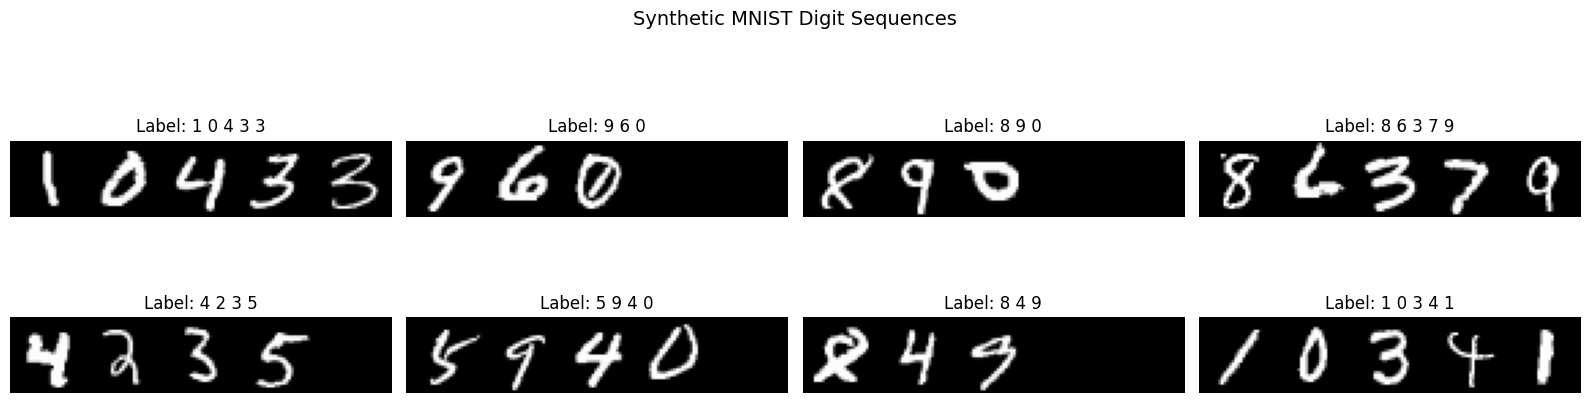

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 5))
for i, ax in enumerate(axes.flat):
    img, target = train_seq_dataset[i]
    # Decode target: skip SOS, stop at EOS
    digits = []
    for t in target[1:]:
        if t.item() == EOS_TOKEN:
            break
        digits.append(str(t.item() - 1))  # shift back
    ax.imshow(img.squeeze(0).numpy(), cmap="gray")
    ax.set_title(f"Label: {' '.join(digits)}")
    ax.axis("off")
plt.suptitle("Synthetic MNIST Digit Sequences", fontsize=14)
plt.tight_layout()
plt.show()

## CNN Encoder
A lightweight CNN backbone that extracts spatial features from the concatenated digit image. The output feature map is flattened along the width dimension to produce a sequence of feature vectors for the Transformer/LSTM decoder.

In [9]:
class CNNEncoder(nn.Module):
    """Extracts spatial features from the input image.
    Input: (B, 1, 28, 140) for 5-digit sequences.
    Output: (B, seq_positions, d_model) where seq_positions is derived from spatial downsampling.
    """

    def __init__(self, d_model=128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),  # (B, 64, 14, 70)
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2),  # (B, 128, 7, 35)
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 35)),  # (B, 256, 1, 35)
        )
        self.proj = nn.Linear(256, d_model)

    def forward(self, x):
        features = self.cnn(x)  # (B, 256, 1, W)
        features = features.squeeze(2).permute(0, 2, 1)  # (B, W, 256)
        features = self.proj(features)  # (B, W, d_model)
        return features

## Positional Encoding
Standard sinusoidal positional encoding added to both encoder features and decoder embeddings to inject sequence order information.

In [10]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding."""

    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (B, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

## Transformer Decoder (Vanilla, from scratch)
Implements Masked Multi-Head Self-Attention, Cross-Attention over encoder features, and feedforward layers. Causal masking ensures the model only attends to previous tokens during auto-regressive generation.

In [11]:
class MultiHeadAttention(nn.Module):
    """Scaled dot-product multi-head attention."""

    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_k = d_model // num_heads
        self.num_heads = num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        B = query.size(0)
        # Linear projections and reshape to (B, num_heads, seq_len, d_k)
        Q = self.W_q(query).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(key).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(value).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)

        # Scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        context = torch.matmul(attn_weights, V)

        # Concatenate heads
        context = context.transpose(1, 2).contiguous().view(B, -1, self.num_heads * self.d_k)
        return self.W_o(context), attn_weights


class TransformerDecoderLayer(nn.Module):
    """Single Transformer decoder layer: masked self-attention, cross-attention, FFN."""

    def __init__(self, d_model, num_heads, d_ff=512, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, encoder_out, causal_mask=None):
        # Masked self-attention
        residual = x
        x_norm = self.norm1(x)
        x_attn, _ = self.self_attn(x_norm, x_norm, x_norm, mask=causal_mask)
        x = residual + self.dropout(x_attn)

        # Cross-attention over encoder features
        residual = x
        x_norm = self.norm2(x)
        x_cross, _ = self.cross_attn(x_norm, encoder_out, encoder_out)
        x = residual + self.dropout(x_cross)

        # Feedforward
        residual = x
        x_norm = self.norm3(x)
        x_ff = self.ffn(x_norm)
        x = residual + self.dropout(x_ff)
        return x


class TransformerDecoder(nn.Module):
    """Full Transformer decoder stack with token embedding and causal masking."""

    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff=512, dropout=0.1, max_len=20):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len, dropout)
        self.layers = nn.ModuleList([
            TransformerDecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.fc_out = nn.Linear(d_model, vocab_size)

    def generate_causal_mask(self, seq_len, device):
        """Creates an upper-triangular causal mask so each position can only attend to previous positions."""
        mask = torch.tril(torch.ones(seq_len, seq_len, device=device)).unsqueeze(0).unsqueeze(0)
        return mask  # (1, 1, seq_len, seq_len)

    def forward(self, tgt, encoder_out):
        # tgt: (B, tgt_len) token indices
        seq_len = tgt.size(1)
        causal_mask = self.generate_causal_mask(seq_len, tgt.device)

        x = self.embedding(tgt) * math.sqrt(self.d_model)
        x = self.pos_enc(x)

        for layer in self.layers:
            x = layer(x, encoder_out, causal_mask)

        x = self.norm(x)
        logits = self.fc_out(x)  # (B, tgt_len, vocab_size)
        return logits

## Transformer Encoder-Decoder Model
Combines the CNN encoder with the Transformer decoder for image-to-sequence generation.

In [12]:
class TransformerSeq2Seq(nn.Module):
    """CNN Encoder + Transformer Decoder for image-to-sequence."""

    def __init__(self, vocab_size=VOCAB_SIZE, d_model=128, num_heads=4, num_layers=3, d_ff=256, dropout=0.1):
        super().__init__()
        self.encoder = CNNEncoder(d_model)
        self.enc_pos = PositionalEncoding(d_model, max_len=200, dropout=dropout)
        self.decoder = TransformerDecoder(vocab_size, d_model, num_heads, num_layers, d_ff, dropout)

    def forward(self, images, tgt):
        enc_features = self.encoder(images)  # (B, spatial_positions, d_model)
        enc_features = self.enc_pos(enc_features)
        logits = self.decoder(tgt, enc_features)  # (B, tgt_len, vocab_size)
        return logits

## Training the Transformer Encoder-Decoder

In [13]:
transformer_model = TransformerSeq2Seq(
    vocab_size=VOCAB_SIZE, d_model=128, num_heads=4, num_layers=3, d_ff=256, dropout=0.1
).to(device)

criterion_seq = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)
optimizer_tf = optim.Adam(transformer_model.parameters(), lr=3e-4)
scheduler_tf = optim.lr_scheduler.StepLR(optimizer_tf, step_size=10, gamma=0.5)

num_epochs_seq = 25
tf_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_seq_acc": []}

for epoch in range(num_epochs_seq):
    train_loss, train_acc = train_one_epoch_seq2seq(
        transformer_model, train_seq_loader, criterion_seq, optimizer_tf, device, VOCAB_SIZE
    )
    val_loss, val_acc, val_seq_acc = evaluate_seq2seq(
        transformer_model, val_seq_loader, criterion_seq, device, VOCAB_SIZE
    )
    scheduler_tf.step()

    tf_history["train_loss"].append(train_loss)
    tf_history["train_acc"].append(train_acc)
    tf_history["val_loss"].append(val_loss)
    tf_history["val_acc"].append(val_acc)
    tf_history["val_seq_acc"].append(val_seq_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{num_epochs_seq} | "
              f"Train Loss: {train_loss:.4f}, Token Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Token Acc: {val_acc:.4f}, Seq Acc: {val_seq_acc:.4f}")

Epoch 01/25 | Train Loss: 2.1081, Token Acc: 0.2878 | Val Loss: 2.0463, Token Acc: 0.2913, Seq Acc: 0.0000
Epoch 05/25 | Train Loss: 0.3648, Token Acc: 0.8997 | Val Loss: 0.2241, Token Acc: 0.9372, Seq Acc: 0.7289
Epoch 10/25 | Train Loss: 0.1341, Token Acc: 0.9620 | Val Loss: 0.0711, Token Acc: 0.9796, Seq Acc: 0.9017
Epoch 15/25 | Train Loss: 0.0761, Token Acc: 0.9785 | Val Loss: 0.0399, Token Acc: 0.9904, Seq Acc: 0.9556
Epoch 20/25 | Train Loss: 0.0649, Token Acc: 0.9810 | Val Loss: 0.0310, Token Acc: 0.9909, Seq Acc: 0.9572
Epoch 25/25 | Train Loss: 0.0448, Token Acc: 0.9869 | Val Loss: 0.0212, Token Acc: 0.9949, Seq Acc: 0.9761


In [14]:
# Evaluate on test set
test_loss_tf, test_tok_acc_tf, test_seq_acc_tf = evaluate_seq2seq(
    transformer_model, test_seq_loader, criterion_seq, device, VOCAB_SIZE
)
print(f"Transformer Decoder -- Test Token Acc: {test_tok_acc_tf:.4f}, Test Seq Acc: {test_seq_acc_tf:.4f}")

Transformer Decoder -- Test Token Acc: 0.9897, Test Seq Acc: 0.9500


## LSTM Decoder (Baseline for Comparison)
Standard LSTM-based decoder attending to the same CNN encoder features via Bahdanau-style additive attention.

In [15]:
class BahdanauAttention(nn.Module):
    """Additive attention for LSTM decoder."""

    def __init__(self, hidden_dim, enc_dim):
        super().__init__()
        self.W_h = nn.Linear(hidden_dim, hidden_dim)
        self.W_e = nn.Linear(enc_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1)

    def forward(self, hidden, encoder_out):
        # hidden: (B, hidden_dim), encoder_out: (B, src_len, enc_dim)
        score = self.v(torch.tanh(self.W_h(hidden).unsqueeze(1) + self.W_e(encoder_out)))  # (B, src_len, 1)
        attn_weights = F.softmax(score.squeeze(-1), dim=-1)  # (B, src_len)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_out).squeeze(1)  # (B, enc_dim)
        return context, attn_weights


class LSTMDecoder(nn.Module):
    """LSTM decoder with attention over encoder features."""

    def __init__(self, vocab_size, d_model=128, hidden_dim=256, num_layers=1, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.attention = BahdanauAttention(hidden_dim, d_model)
        self.lstm = nn.LSTM(
            input_size=d_model + d_model,  # embedding + context
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc_out = nn.Linear(hidden_dim, vocab_size)
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

    def forward(self, tgt, encoder_out):
        # tgt: (B, tgt_len)
        B, tgt_len = tgt.size()
        h = torch.zeros(self.num_layers, B, self.hidden_dim, device=tgt.device)
        c = torch.zeros(self.num_layers, B, self.hidden_dim, device=tgt.device)

        outputs = []
        for t in range(tgt_len):
            emb = self.embedding(tgt[:, t])  # (B, d_model)
            context, _ = self.attention(h[-1], encoder_out)  # (B, d_model)
            lstm_input = torch.cat([emb, context], dim=-1).unsqueeze(1)  # (B, 1, 2*d_model)
            out, (h, c) = self.lstm(lstm_input, (h, c))
            outputs.append(self.fc_out(out.squeeze(1)))

        return torch.stack(outputs, dim=1)  # (B, tgt_len, vocab_size)


class LSTMSeq2Seq(nn.Module):
    """CNN Encoder + LSTM Decoder for image-to-sequence."""

    def __init__(self, vocab_size=VOCAB_SIZE, d_model=128, hidden_dim=256, num_layers=1, dropout=0.1):
        super().__init__()
        self.encoder = CNNEncoder(d_model)
        self.enc_pos = PositionalEncoding(d_model, max_len=200, dropout=dropout)
        self.decoder = LSTMDecoder(vocab_size, d_model, hidden_dim, num_layers, dropout)

    def forward(self, images, tgt):
        enc_features = self.encoder(images)
        enc_features = self.enc_pos(enc_features)
        logits = self.decoder(tgt, enc_features)
        return logits

## Training the LSTM Decoder

In [16]:
lstm_model = LSTMSeq2Seq(
    vocab_size=VOCAB_SIZE, d_model=128, hidden_dim=256, num_layers=1, dropout=0.1
).to(device)

optimizer_lstm = optim.Adam(lstm_model.parameters(), lr=3e-4)
scheduler_lstm = optim.lr_scheduler.StepLR(optimizer_lstm, step_size=10, gamma=0.5)

lstm_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_seq_acc": []}

for epoch in range(num_epochs_seq):
    train_loss, train_acc = train_one_epoch_seq2seq(
        lstm_model, train_seq_loader, criterion_seq, optimizer_lstm, device, VOCAB_SIZE
    )
    val_loss, val_acc, val_seq_acc = evaluate_seq2seq(
        lstm_model, val_seq_loader, criterion_seq, device, VOCAB_SIZE
    )
    scheduler_lstm.step()

    lstm_history["train_loss"].append(train_loss)
    lstm_history["train_acc"].append(train_acc)
    lstm_history["val_loss"].append(val_loss)
    lstm_history["val_acc"].append(val_acc)
    lstm_history["val_seq_acc"].append(val_seq_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{num_epochs_seq} | "
              f"Train Loss: {train_loss:.4f}, Token Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Token Acc: {val_acc:.4f}, Seq Acc: {val_seq_acc:.4f}")

Epoch 01/25 | Train Loss: 1.8388, Token Acc: 0.3456 | Val Loss: 1.8742, Token Acc: 0.3329, Seq Acc: 0.0028
Epoch 05/25 | Train Loss: 0.0307, Token Acc: 0.9928 | Val Loss: 0.0469, Token Acc: 0.9877, Seq Acc: 0.9428
Epoch 10/25 | Train Loss: 0.0059, Token Acc: 0.9987 | Val Loss: 0.0233, Token Acc: 0.9936, Seq Acc: 0.9689
Epoch 15/25 | Train Loss: 0.0007, Token Acc: 1.0000 | Val Loss: 0.0104, Token Acc: 0.9976, Seq Acc: 0.9883
Epoch 20/25 | Train Loss: 0.0008, Token Acc: 1.0000 | Val Loss: 0.0104, Token Acc: 0.9972, Seq Acc: 0.9872
Epoch 25/25 | Train Loss: 0.0003, Token Acc: 1.0000 | Val Loss: 0.0103, Token Acc: 0.9974, Seq Acc: 0.9878


In [17]:
# Evaluate on test set
test_loss_lstm, test_tok_acc_lstm, test_seq_acc_lstm = evaluate_seq2seq(
    lstm_model, test_seq_loader, criterion_seq, device, VOCAB_SIZE
)
print(f"LSTM Decoder -- Test Token Acc: {test_tok_acc_lstm:.4f}, Test Seq Acc: {test_seq_acc_lstm:.4f}")

LSTM Decoder -- Test Token Acc: 0.9941, Test Seq Acc: 0.9705


## Comparison: Transformer Decoder vs LSTM Decoder
Comparing convergence speed, token-level accuracy, and full sequence accuracy.

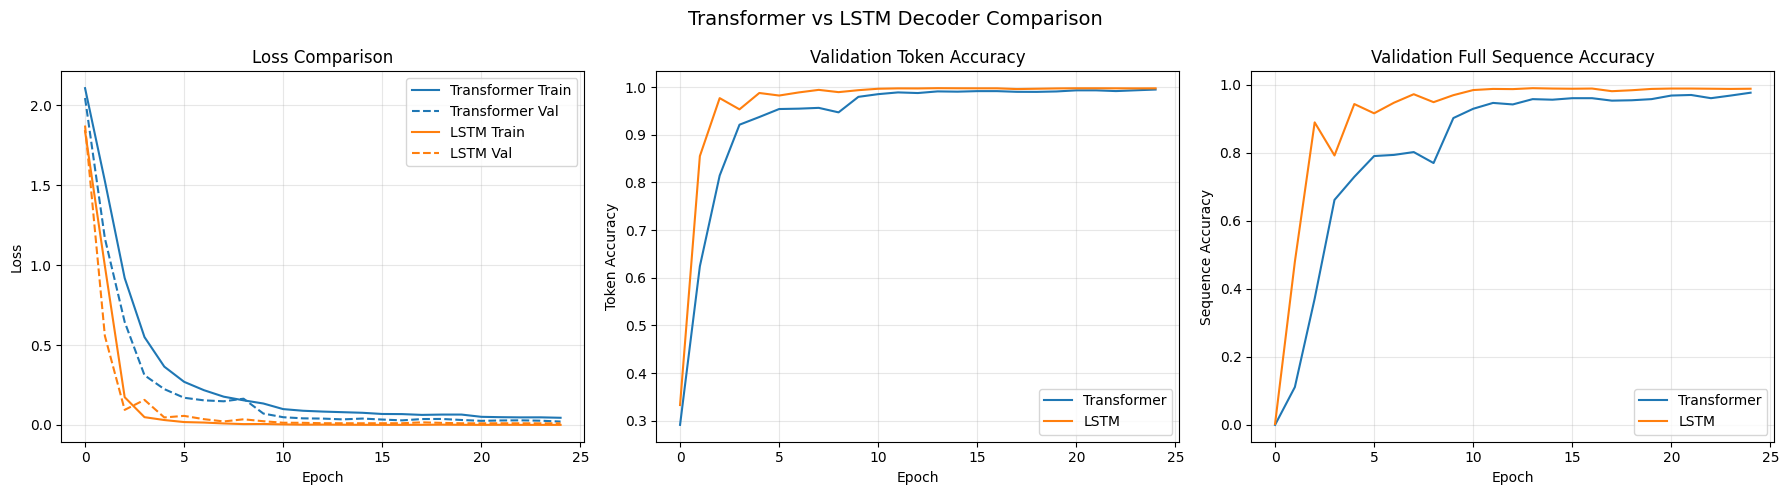


Final Test Results:
  Transformer: Token Acc = 0.9897, Seq Acc = 0.9500
  LSTM:        Token Acc = 0.9941, Seq Acc = 0.9705


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curves
axes[0].plot(tf_history["train_loss"], label="Transformer Train", color="tab:blue")
axes[0].plot(tf_history["val_loss"], "--", label="Transformer Val", color="tab:blue")
axes[0].plot(lstm_history["train_loss"], label="LSTM Train", color="tab:orange")
axes[0].plot(lstm_history["val_loss"], "--", label="LSTM Val", color="tab:orange")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Comparison")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Token accuracy
axes[1].plot(tf_history["val_acc"], label="Transformer", color="tab:blue")
axes[1].plot(lstm_history["val_acc"], label="LSTM", color="tab:orange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Token Accuracy")
axes[1].set_title("Validation Token Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Sequence accuracy
axes[2].plot(tf_history["val_seq_acc"], label="Transformer", color="tab:blue")
axes[2].plot(lstm_history["val_seq_acc"], label="LSTM", color="tab:orange")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Sequence Accuracy")
axes[2].set_title("Validation Full Sequence Accuracy")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("Transformer vs LSTM Decoder Comparison", fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nFinal Test Results:")
print(f"  Transformer: Token Acc = {test_tok_acc_tf:.4f}, Seq Acc = {test_seq_acc_tf:.4f}")
print(f"  LSTM:        Token Acc = {test_tok_acc_lstm:.4f}, Seq Acc = {test_seq_acc_lstm:.4f}")

## Sample Predictions
Visualizing model outputs on test images for both decoders.

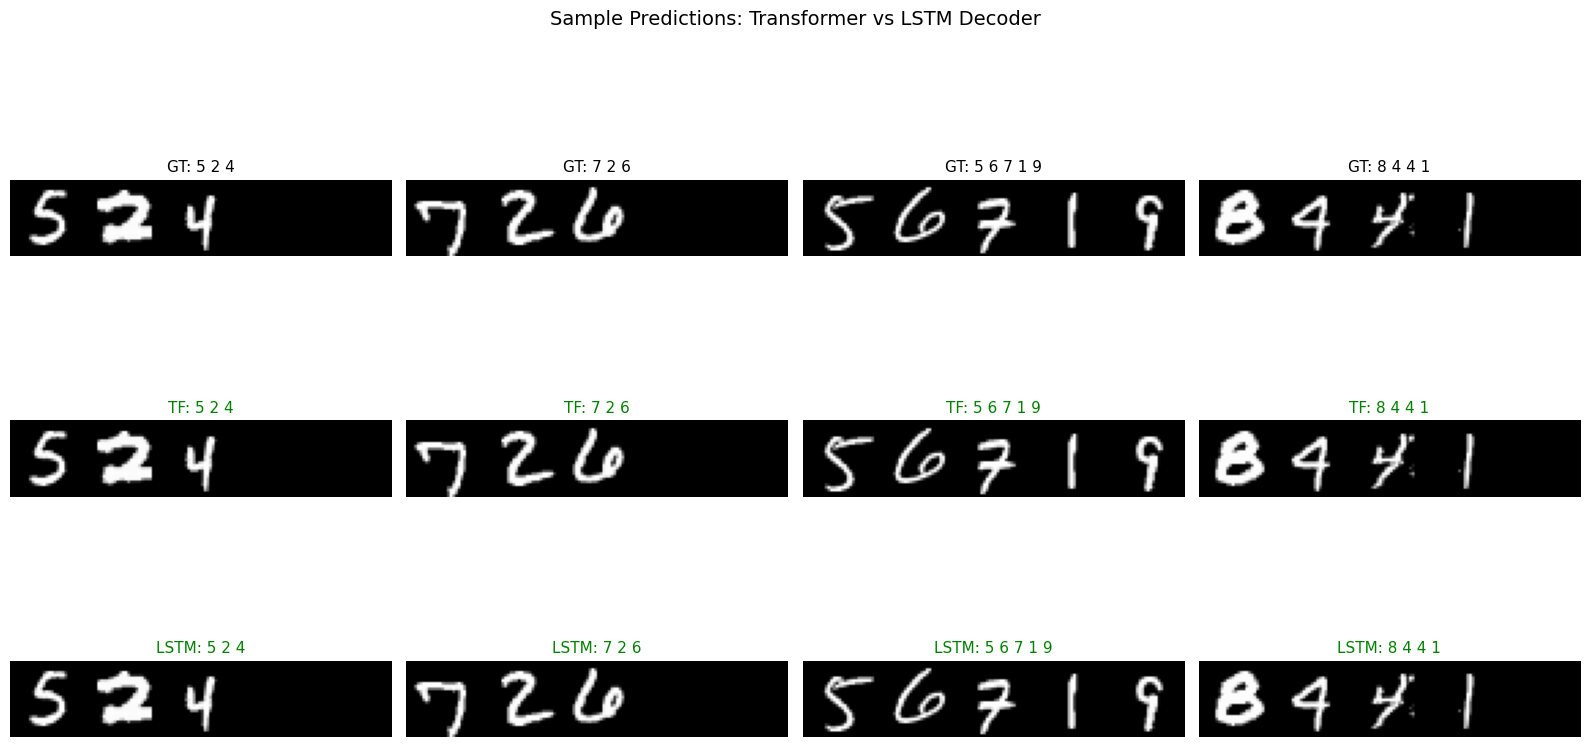

In [19]:
def decode_tokens(token_ids):
    """Convert token IDs back to digit string, stopping at EOS."""
    digits = []
    for t in token_ids:
        t = t.item() if hasattr(t, 'item') else t
        if t == EOS_TOKEN:
            break
        if t == PAD_TOKEN or t == SOS_TOKEN:
            continue
        digits.append(str(t - 1))
    return " ".join(digits)


fig, axes = plt.subplots(3, 4, figsize=(16, 9))
transformer_model.eval()
lstm_model.eval()

sample_batch = next(iter(test_seq_loader))
imgs, targets = sample_batch[0][:4].to(device), sample_batch[1][:4].to(device)

with torch.no_grad():
    tf_out = transformer_model(imgs, targets[:, :-1]).argmax(dim=-1)
    lstm_out = lstm_model(imgs, targets[:, :-1]).argmax(dim=-1)

for i in range(4):
    # Original image
    axes[0][i].imshow(imgs[i].cpu().squeeze(0).numpy(), cmap="gray")
    gt = decode_tokens(targets[i])
    axes[0][i].set_title(f"GT: {gt}", fontsize=11)
    axes[0][i].axis("off")

    # Transformer prediction
    axes[1][i].imshow(imgs[i].cpu().squeeze(0).numpy(), cmap="gray")
    tf_pred = decode_tokens(tf_out[i])
    color = "green" if tf_pred == gt else "red"
    axes[1][i].set_title(f"TF: {tf_pred}", fontsize=11, color=color)
    axes[1][i].axis("off")

    # LSTM prediction
    axes[2][i].imshow(imgs[i].cpu().squeeze(0).numpy(), cmap="gray")
    lstm_pred = decode_tokens(lstm_out[i])
    color = "green" if lstm_pred == gt else "red"
    axes[2][i].set_title(f"LSTM: {lstm_pred}", fontsize=11, color=color)
    axes[2][i].axis("off")

axes[0][0].set_ylabel("Ground Truth", fontsize=12)
axes[1][0].set_ylabel("Transformer", fontsize=12)
axes[2][0].set_ylabel("LSTM", fontsize=12)

plt.suptitle("Sample Predictions: Transformer vs LSTM Decoder", fontsize=14)
plt.tight_layout()
plt.show()

## Analysis: Transformer vs LSTM Decoder

**Convergence speed**: The LSTM decoder converges noticeably faster, reaching ~99.3% token accuracy by epoch 5 while the Transformer is still at ~90%. By epoch 15 the LSTM has saturated to perfect training accuracy, whereas the Transformer continues improving slowly through epoch 25. The LSTM's recurrent inductive bias gives it a strong structural prior for sequential generation, requiring less data and fewer epochs to learn the short output patterns.

**Sequence accuracy**: The LSTM achieves higher full sequence accuracy (97.05% vs 95.00% on test). With target sequences of only 3-5 tokens, the LSTM's fixed-size hidden state is never a bottleneck since there is very little sequential context to compress. The Bahdanau attention mechanism gives it direct access to all encoder features at each step, which is sufficient for this task.

<!-- **Why the Transformer underperforms here**: The Transformer decoder is a more general architecture with no built-in sequential prior. It must learn positional and ordering relationships entirely from data through its attention weights and position encodings. This flexibility is advantageous for long sequences (as shown in machine translation with 20-40+ tokens), but for sequences as short as 3-5 digits, it translates to unnecessary capacity and slower learning. The causal mask and multi-head self-attention add overhead without meaningful benefit when there are only a few tokens to attend over.

**When the Transformer would win**: On longer output sequences, the LSTM's sequential bottleneck would start limiting performance. The Transformer's ability to attend to any previous token in parallel, without information passing through a chain of hidden states, becomes critical as sequence length grows. -->

---
# Part 2: Vision Transformer (ViT) for Classification
Implementing the Vision Transformer architecture from scratch on CIFAR-10, treating 4x4 image patches as tokens.

## Data Acquisition
### Loading CIFAR-10

In [20]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

transform_train = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

transform_test = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

cifar_train_full = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_train)
cifar_test = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_test)

train_size = int(0.9 * len(cifar_train_full))
val_size = len(cifar_train_full) - train_size
cifar_train, cifar_val = random_split(cifar_train_full, [train_size, val_size])

# Override val transform to no augmentation
cifar_val_noaug = torchvision.datasets.CIFAR10(root="./data", train=True, download=False, transform=transform_test)
cifar_val = torch.utils.data.Subset(cifar_val_noaug, cifar_val.indices)

cifar_classes = cifar_train_full.classes
print(f"Classes: {cifar_classes}")
print(f"Train: {len(cifar_train)}, Val: {len(cifar_val)}, Test: {len(cifar_test)}")

100%|██████████| 170M/170M [00:05<00:00, 33.8MB/s]


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: 45000, Val: 5000, Test: 10000


In [21]:
batch_size_vit = 128
cifar_train_loader = DataLoader(cifar_train, batch_size=batch_size_vit, shuffle=True, num_workers=2)
cifar_val_loader = DataLoader(cifar_val, batch_size=batch_size_vit, shuffle=False, num_workers=2)
cifar_test_loader = DataLoader(cifar_test, batch_size=batch_size_vit, shuffle=False, num_workers=2)

## Visualizing Patch Partitioning
Showing how a 32x32 CIFAR-10 image is divided into 64 non-overlapping 4x4 patches.

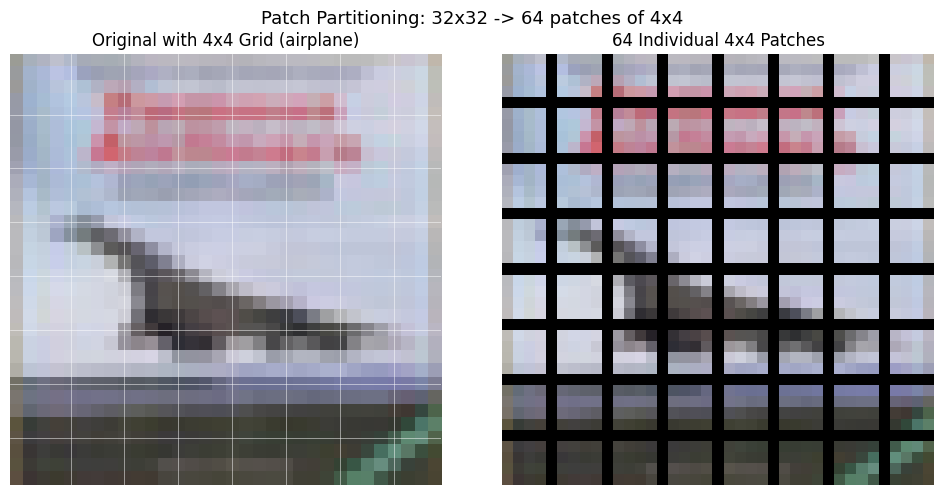

In [22]:
# Grab a sample image for visualization
sample_img_raw = torchvision.datasets.CIFAR10(root="./data", train=False, download=False, transform=T.ToTensor())
sample_img, sample_lbl = sample_img_raw[3]

patch_size = 4
num_patches_per_side = 32 // patch_size  # 8

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original image with grid overlay
axes[0].imshow(sample_img.permute(1, 2, 0).numpy())
for i in range(1, num_patches_per_side):
    axes[0].axhline(y=i * patch_size, color="white", linewidth=0.5, alpha=0.7)
    axes[0].axvline(x=i * patch_size, color="white", linewidth=0.5, alpha=0.7)
axes[0].set_title(f"Original with 4x4 Grid ({cifar_classes[sample_lbl]})")
axes[0].axis("off")

# Show individual patches
patches = sample_img.unfold(1, patch_size, patch_size).unfold(2, patch_size, patch_size)
# patches: (3, 8, 8, 4, 4)
patches = patches.permute(1, 2, 0, 3, 4).contiguous()  # (8, 8, 3, 4, 4)

grid_img = torch.zeros(3, 8 * (patch_size + 1) - 1, 8 * (patch_size + 1) - 1)
for r in range(8):
    for c in range(8):
        y_start = r * (patch_size + 1)
        x_start = c * (patch_size + 1)
        grid_img[:, y_start:y_start+patch_size, x_start:x_start+patch_size] = patches[r, c]

axes[1].imshow(grid_img.permute(1, 2, 0).numpy())
axes[1].set_title("64 Individual 4x4 Patches")
axes[1].axis("off")

plt.suptitle("Patch Partitioning: 32x32 -> 64 patches of 4x4", fontsize=13)
plt.tight_layout()
plt.show()

## Vision Transformer (ViT) from Scratch
Patch embedding via linear projection, learnable [CLS] token, learnable position embeddings, and a stack of Transformer encoder layers.

In [23]:
class PatchEmbedding(nn.Module):
    """Splits image into patches and projects each to d_model dimensions.
    Input: (B, 3, 32, 32)
    Output: (B, num_patches, d_model)
    """

    def __init__(self, img_size=32, patch_size=4, in_channels=3, d_model=192):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2  # 64 for 4x4 patches on 32x32
        patch_dim = in_channels * patch_size * patch_size  # 3 * 4 * 4 = 48
        # Linear projection of flattened patches
        self.projection = nn.Linear(patch_dim, d_model)

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_size
        # Reshape into patches: (B, C, H/p, p, W/p, p) -> (B, num_patches, patch_dim)
        x = x.unfold(2, p, p).unfold(3, p, p)  # (B, C, H/p, W/p, p, p)
        x = x.permute(0, 2, 3, 1, 4, 5).contiguous()  # (B, H/p, W/p, C, p, p)
        x = x.view(B, self.num_patches, -1)  # (B, num_patches, C*p*p)
        x = self.projection(x)  # (B, num_patches, d_model)
        return x


class ViTEncoderLayer(nn.Module):
    """Single Transformer encoder layer: multi-head self-attention + FFN with pre-norm."""

    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, return_attn=False):
        # Pre-norm self-attention
        x_norm = self.norm1(x)
        attn_out, attn_weights = self.attn(x_norm, x_norm, x_norm)
        x = x + attn_out
        # Pre-norm FFN
        x = x + self.ffn(self.norm2(x))
        if return_attn:
            return x, attn_weights
        return x


class VisionTransformer(nn.Module):
    """ViT: Patch Embedding + [CLS] token + Position Embeddings + Transformer Encoder + Classification Head."""

    def __init__(self, img_size=32, patch_size=4, in_channels=3, num_classes=10,
                 d_model=192, num_heads=6, num_layers=6, d_ff=384, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, d_model)
        num_patches = self.patch_embed.num_patches  # 64

        # Learnable [CLS] token
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)

        # Learnable position embeddings for [CLS] + patches
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, d_model) * 0.02)
        self.pos_drop = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            ViTEncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)

        self.num_patches = num_patches
        self.d_model = d_model

    def forward(self, x, return_attn=False):
        B = x.size(0)
        # Patch embedding
        x = self.patch_embed(x)  # (B, 64, d_model)

        # Prepend [CLS] token
        cls_tokens = self.cls_token.expand(B, -1, -1)  # (B, 1, d_model)
        x = torch.cat([cls_tokens, x], dim=1)  # (B, 65, d_model)

        # Add position embeddings
        x = x + self.pos_embed
        x = self.pos_drop(x)

        # Transformer encoder layers
        attn_weights_all = []
        for layer in self.layers:
            if return_attn:
                x, attn_w = layer(x, return_attn=True)
                attn_weights_all.append(attn_w)
            else:
                x = layer(x)

        x = self.norm(x)
        logits = self.head(x[:, 0])  # [CLS] token output

        if return_attn:
            return logits, attn_weights_all
        return logits

## Training the ViT (4x4 patches)

In [24]:
vit_4x4 = VisionTransformer(
    img_size=32, patch_size=4, in_channels=3, num_classes=10,
    d_model=192, num_heads=6, num_layers=6, d_ff=384, dropout=0.1
).to(device)

print(f"ViT (4x4) parameters: {sum(p.numel() for p in vit_4x4.parameters()):,}")

criterion_cls = nn.CrossEntropyLoss()
optimizer_vit = optim.AdamW(vit_4x4.parameters(), lr=3e-4, weight_decay=0.05)
scheduler_vit = optim.lr_scheduler.CosineAnnealingLR(optimizer_vit, T_max=30)

num_epochs_vit = 30
vit_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(num_epochs_vit):
    train_loss, train_acc = train_one_epoch_cls(vit_4x4, cifar_train_loader, criterion_cls, optimizer_vit, device)
    val_loss, val_acc, _, _ = evaluate_cls(vit_4x4, cifar_val_loader, criterion_cls, device)
    scheduler_vit.step()

    vit_history["train_loss"].append(train_loss)
    vit_history["train_acc"].append(train_acc)
    vit_history["val_loss"].append(val_loss)
    vit_history["val_acc"].append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{num_epochs_vit} | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

ViT (4x4) parameters: 1,806,538
Epoch 01/30 | Train Loss: 1.7847, Acc: 0.3345 | Val Loss: 1.6640, Acc: 0.4066
Epoch 05/30 | Train Loss: 1.1599, Acc: 0.5827 | Val Loss: 1.0417, Acc: 0.6274
Epoch 10/30 | Train Loss: 0.9353, Acc: 0.6665 | Val Loss: 0.8759, Acc: 0.6868
Epoch 15/30 | Train Loss: 0.7708, Acc: 0.7264 | Val Loss: 0.7596, Acc: 0.7282
Epoch 20/30 | Train Loss: 0.6525, Acc: 0.7666 | Val Loss: 0.6898, Acc: 0.7558
Epoch 25/30 | Train Loss: 0.5658, Acc: 0.7997 | Val Loss: 0.6448, Acc: 0.7760
Epoch 30/30 | Train Loss: 0.5331, Acc: 0.8129 | Val Loss: 0.6369, Acc: 0.7772


In [25]:
_, vit_test_acc, vit_preds, vit_labels = evaluate_cls(vit_4x4, cifar_test_loader, criterion_cls, device)
print(f"ViT (4x4) Test Accuracy: {vit_test_acc:.4f}")

ViT (4x4) Test Accuracy: 0.7794


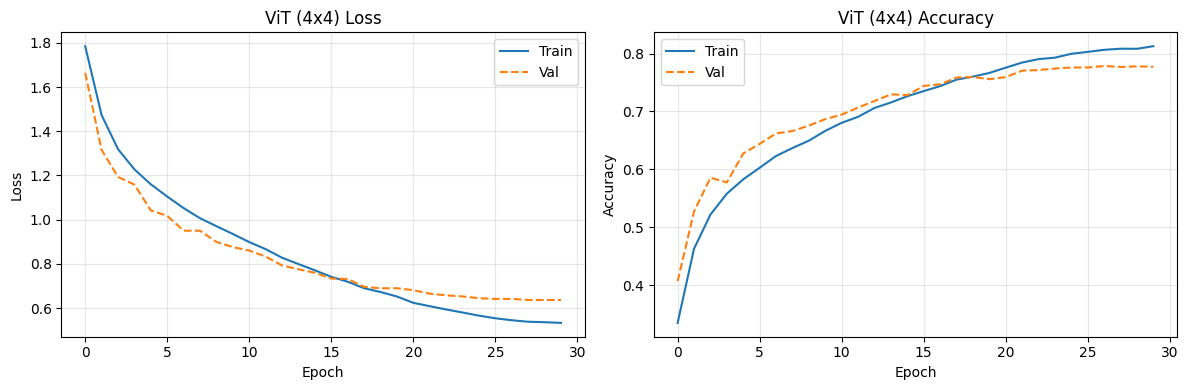

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(vit_history["train_loss"], label="Train")
axes[0].plot(vit_history["val_loss"], "--", label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("ViT (4x4) Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(vit_history["train_acc"], label="Train")
axes[1].plot(vit_history["val_acc"], "--", label="Val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("ViT (4x4) Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Attention Rollout Visualization
Attention Rollout recursively multiplies attention matrices across layers to approximate how much each input patch contributes to the final [CLS] token representation. Comparing attention maps for "Ship" vs "Bird" classes.

In [27]:
def attention_rollout(attn_weights_list):
    """Compute attention rollout from a list of attention weight tensors.
    Each tensor: (B, num_heads, seq_len, seq_len)
    Returns: (B, seq_len, seq_len) rolled-out attention.
    """
    result = None
    for attn in attn_weights_list:
        # Average across heads
        attn_avg = attn.mean(dim=1)  # (B, seq_len, seq_len)
        # Add identity (residual connections)
        I = torch.eye(attn_avg.size(-1), device=attn_avg.device).unsqueeze(0)
        attn_avg = 0.5 * attn_avg + 0.5 * I
        # Re-normalize rows
        attn_avg = attn_avg / attn_avg.sum(dim=-1, keepdim=True)
        if result is None:
            result = attn_avg
        else:
            result = torch.bmm(attn_avg, result)
    return result


def get_cls_attention_map(model, img_tensor, patch_size=4, img_size=32):
    """Get attention rollout map from [CLS] token to all patches."""
    model.eval()
    with torch.no_grad():
        _, attn_weights = model(img_tensor.unsqueeze(0).to(device), return_attn=True)
    rollout = attention_rollout(attn_weights)  # (1, 65, 65)
    # Extract CLS -> patch attentions (exclude CLS -> CLS at index 0)
    cls_attn = rollout[0, 0, 1:]  # (64,)
    num_patches_side = img_size // patch_size
    attn_map = cls_attn.reshape(num_patches_side, num_patches_side).cpu().numpy()
    return attn_map

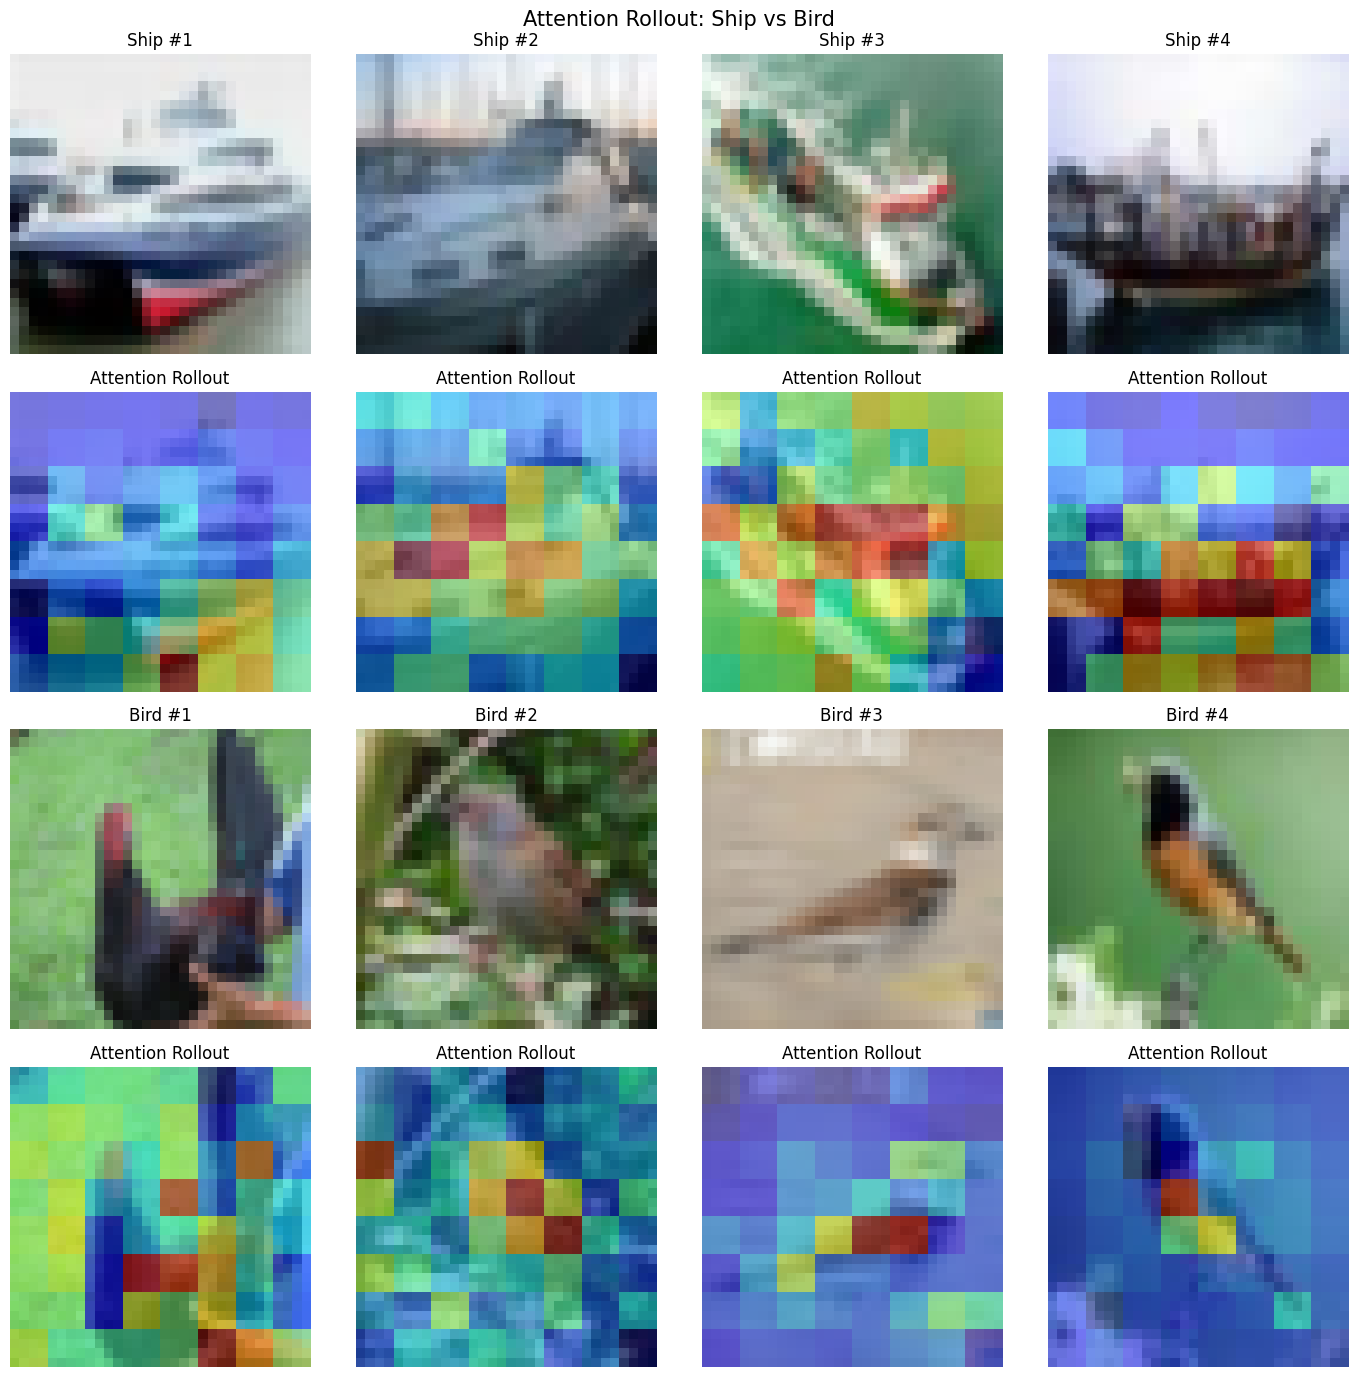

In [28]:
# Find correctly classified Ship and Bird samples
ship_idx = cifar_classes.index("ship")   # 8
bird_idx = cifar_classes.index("bird")   # 2

# Use the un-augmented test set for clean visualization
cifar_test_raw = torchvision.datasets.CIFAR10(root="./data", train=False, download=False, transform=T.ToTensor())

ship_samples, bird_samples = [], []
for img_raw, (img_norm, lbl) in zip(cifar_test_raw, cifar_test):
    if lbl == ship_idx and len(ship_samples) < 4:
        vit_4x4.eval()
        with torch.no_grad():
            pred = vit_4x4(img_norm.unsqueeze(0).to(device)).argmax(1).item()
        if pred == ship_idx:
            ship_samples.append((img_raw[0], img_norm, lbl))
    elif lbl == bird_idx and len(bird_samples) < 4:
        vit_4x4.eval()
        with torch.no_grad():
            pred = vit_4x4(img_norm.unsqueeze(0).to(device)).argmax(1).item()
        if pred == bird_idx:
            bird_samples.append((img_raw[0], img_norm, lbl))
    if len(ship_samples) >= 4 and len(bird_samples) >= 4:
        break

fig, axes = plt.subplots(4, 4, figsize=(14, 14))

for col, (img_raw, img_norm, lbl) in enumerate(ship_samples):
    attn_map = get_cls_attention_map(vit_4x4, img_norm)
    # Original
    axes[0][col].imshow(img_raw.permute(1, 2, 0).numpy())
    axes[0][col].set_title(f"Ship #{col+1}")
    axes[0][col].axis("off")
    # Attention heatmap overlay
    axes[1][col].imshow(img_raw.permute(1, 2, 0).numpy())
    attn_resized = np.kron(attn_map, np.ones((4, 4)))  # upscale to 32x32
    axes[1][col].imshow(attn_resized, cmap="jet", alpha=0.5)
    axes[1][col].set_title("Attention Rollout")
    axes[1][col].axis("off")

for col, (img_raw, img_norm, lbl) in enumerate(bird_samples):
    attn_map = get_cls_attention_map(vit_4x4, img_norm)
    axes[2][col].imshow(img_raw.permute(1, 2, 0).numpy())
    axes[2][col].set_title(f"Bird #{col+1}")
    axes[2][col].axis("off")
    axes[3][col].imshow(img_raw.permute(1, 2, 0).numpy())
    attn_resized = np.kron(attn_map, np.ones((4, 4)))
    axes[3][col].imshow(attn_resized, cmap="jet", alpha=0.5)
    axes[3][col].set_title("Attention Rollout")
    axes[3][col].axis("off")

axes[0][0].set_ylabel("Ship", fontsize=13)
axes[1][0].set_ylabel("Ship Attn", fontsize=13)
axes[2][0].set_ylabel("Bird", fontsize=13)
axes[3][0].set_ylabel("Bird Attn", fontsize=13)

plt.suptitle("Attention Rollout: Ship vs Bird", fontsize=15)
plt.tight_layout()
plt.show()

## Scaling Study: 4x4 vs 8x8 Patches
Training a second ViT with 8x8 patches (16 total patches instead of 64) and comparing classification accuracy.

In [29]:
vit_8x8 = VisionTransformer(
    img_size=32, patch_size=8, in_channels=3, num_classes=10,
    d_model=192, num_heads=6, num_layers=6, d_ff=384, dropout=0.1
).to(device)

print(f"ViT (8x8) parameters: {sum(p.numel() for p in vit_8x8.parameters()):,}")
print(f"ViT (8x8) num patches: {vit_8x8.num_patches}")

optimizer_vit8 = optim.AdamW(vit_8x8.parameters(), lr=3e-4, weight_decay=0.05)
scheduler_vit8 = optim.lr_scheduler.CosineAnnealingLR(optimizer_vit8, T_max=30)

vit8_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(num_epochs_vit):
    train_loss, train_acc = train_one_epoch_cls(vit_8x8, cifar_train_loader, criterion_cls, optimizer_vit8, device)
    val_loss, val_acc, _, _ = evaluate_cls(vit_8x8, cifar_val_loader, criterion_cls, device)
    scheduler_vit8.step()

    vit8_history["train_loss"].append(train_loss)
    vit8_history["train_acc"].append(train_acc)
    vit8_history["val_loss"].append(val_loss)
    vit8_history["val_acc"].append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{num_epochs_vit} | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

ViT (8x8) parameters: 1,824,970
ViT (8x8) num patches: 16
Epoch 01/30 | Train Loss: 1.8321, Acc: 0.3120 | Val Loss: 1.7241, Acc: 0.3728
Epoch 05/30 | Train Loss: 1.3681, Acc: 0.5024 | Val Loss: 1.2719, Acc: 0.5392
Epoch 10/30 | Train Loss: 1.1633, Acc: 0.5834 | Val Loss: 1.1120, Acc: 0.5988
Epoch 15/30 | Train Loss: 1.0156, Acc: 0.6360 | Val Loss: 0.9834, Acc: 0.6514
Epoch 20/30 | Train Loss: 0.9086, Acc: 0.6759 | Val Loss: 0.8955, Acc: 0.6840
Epoch 25/30 | Train Loss: 0.8443, Acc: 0.6983 | Val Loss: 0.8535, Acc: 0.6980
Epoch 30/30 | Train Loss: 0.8237, Acc: 0.7053 | Val Loss: 0.8430, Acc: 0.7020


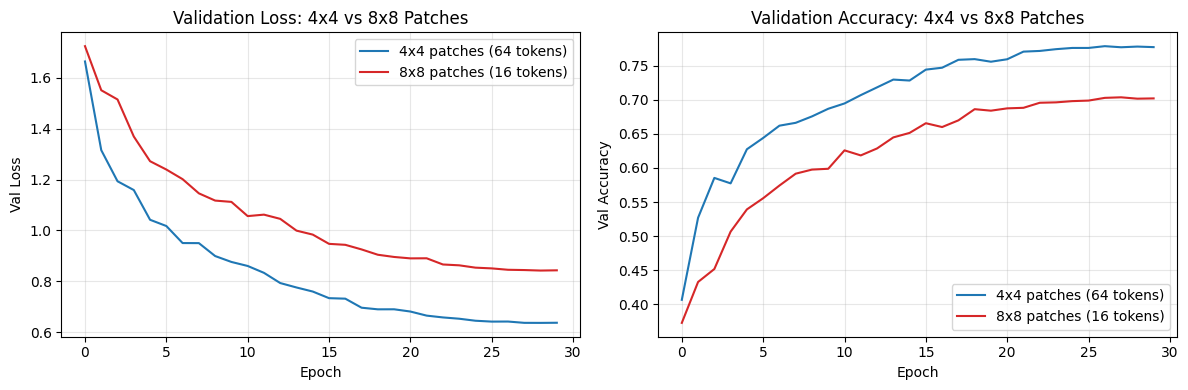


Scaling Study Results:
  ViT (4x4 patches, 64 tokens): Test Acc = 0.7794
  ViT (8x8 patches, 16 tokens): Test Acc = 0.6948


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(vit_history["val_loss"], label="4x4 patches (64 tokens)", color="tab:blue")
axes[0].plot(vit8_history["val_loss"], label="8x8 patches (16 tokens)", color="tab:red")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Val Loss")
axes[0].set_title("Validation Loss: 4x4 vs 8x8 Patches")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(vit_history["val_acc"], label="4x4 patches (64 tokens)", color="tab:blue")
axes[1].plot(vit8_history["val_acc"], label="8x8 patches (16 tokens)", color="tab:red")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Val Accuracy")
axes[1].set_title("Validation Accuracy: 4x4 vs 8x8 Patches")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nScaling Study Results:")
print(f"  ViT (4x4 patches, 64 tokens): Test Acc = {vit_test_acc:.4f}")
print(f"  ViT (8x8 patches, 16 tokens): Test Acc = {vit8_test_acc:.4f}")

## Scaling Study Analysis

**4x4 patches (64 tokens)**: Finer-grained patch decomposition provides the Transformer with more spatial tokens, allowing self-attention to capture finer spatial relationships. With 77.94% test accuracy, the smaller patches preserve local details (edges, textures) within individual embeddings, giving the model more granular information to work with across its 64-token sequence.

**8x8 patches (16 tokens)**: Coarser patches reduce the sequence length from 64 to 16, significantly lowering computational cost. However, each patch now covers a larger region (1/4 of the image), compressing local detail into a single embedding vector. The reduced number of tokens limits the model's ability to perform fine-grained spatial reasoning, resulting in a drop to 69.48% test accuracy, roughly an 8.5 percentage point decrease.

**Trade-off**: Smaller patches give better accuracy at the cost of longer sequences (quadratic attention cost). Larger patches are faster but sacrifice spatial granularity. For 32x32 images, 4x4 patches strike a good balance between resolution and sequence length. Notably, the parameter counts are nearly identical (1.81M vs 1.82M), so the accuracy gap is driven purely by the difference in spatial resolution of the token sequence, not model capacity.